In [1]:
import numpy as np
from IQAEBinom import IQAEBinom
import matplotlib.pyplot as plt
import pickle
from BiasCorrection import BiasExact
import datetime

In [2]:
epsilon = 0.001
nEstim = 10000
alpha = 0.05
nShotUnit = 1

In [3]:
ps = np.linspace(0.001, 0.999, 201)

In [4]:
errAvgs = np.array([])
errStds = np.array([])
biasesMonte = np.array([])
for p in ps:
    print(p, datetime.datetime.now())
    results = np.array([])

    for i in range(nEstim):
        result = IQAEBinom(p, epsilon, alpha, nShotUnit, confint_method="chernoff")
        results = np.append(results, result)

    resFileName = "C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/results_IQAE_pTrue" + str(p) + "_epsilon0001_alpha005.dat"
    with open(resFileName, 'wb') as f:
        pickle.dump(results, f) 
    biases = [BiasExact(p, r["nGrover"][-1], r["nShots"][-1]) for r in results]    
    biasesMonte = np.append(biasesMonte, np.mean(biases))
    errs = [r["Estimate"] - p for r in results]
    errAvgs = np.append(errAvgs, np.mean(errs))
    errStds = np.append(errStds, np.std(errs))


0.001 2023-08-30 17:54:40.012774
0.00599 2023-08-30 17:56:06.156805
0.01098 2023-08-30 17:59:19.275613
0.015969999999999998 2023-08-30 18:00:56.461976
0.02096 2023-08-30 18:02:26.550085
0.02595 2023-08-30 18:04:14.557076
0.03094 2023-08-30 18:06:28.522240
0.03593 2023-08-30 18:08:54.322391
0.04092 2023-08-30 18:11:05.490172
0.04591 2023-08-30 18:13:03.674953
0.0509 2023-08-30 18:14:54.779211
0.055889999999999995 2023-08-30 18:16:54.977355
0.06088 2023-08-30 18:18:48.197471
0.06587 2023-08-30 18:20:45.795637
0.07085999999999999 2023-08-30 18:22:44.324297
0.07585 2023-08-30 18:24:45.487137
0.08084 2023-08-30 18:26:47.465023
0.08582999999999999 2023-08-30 18:28:49.646153
0.09082 2023-08-30 18:30:57.181284
0.09580999999999999 2023-08-30 18:33:11.205808
0.1008 2023-08-30 18:35:24.156042
0.10579 2023-08-30 18:37:24.906250
0.11077999999999999 2023-08-30 18:39:30.323319
0.11577 2023-08-30 18:41:44.710343
0.12075999999999999 2023-08-30 18:44:18.923970
0.12574999999999997 2023-08-30 18:46:55.322

In [5]:
biasesMonte

array([-6.75093638e-06,  3.52298404e-06,  1.11954600e-06, -2.77050526e-06,
        1.63045979e-06,  4.18560414e-07, -3.67079869e-07, -1.63024703e-06,
        1.02614564e-06,  7.31371956e-07,  6.88048014e-07,  4.65823889e-07,
       -4.02345429e-06, -7.70647173e-06,  1.62409592e-06, -1.19809412e-06,
       -8.28021250e-08,  1.73523810e-06,  1.05830632e-06,  1.26590705e-06,
        3.86663816e-07, -6.53564298e-07,  3.21000106e-06, -8.54264796e-07,
       -1.58885537e-06,  3.11777539e-08,  2.72154650e-06, -5.67232150e-06,
        4.35984984e-06, -1.37819188e-06,  2.39725613e-06,  1.39427221e-06,
        2.19187556e-06,  7.34869110e-07, -6.74587504e-08, -2.01310470e-06,
        1.73818800e-06, -3.77856254e-06,  5.23348422e-07, -1.66629098e-07,
        1.37684037e-06, -3.14521357e-06,  1.59210260e-06, -5.12872332e-07,
       -6.94643862e-07,  1.28467290e-06,  5.02144722e-07,  1.16095894e-06,
       -4.99438632e-07, -2.74957411e-06,  3.76619179e-07,  7.76620164e-07,
       -6.46414510e-07, -

In [6]:
errAvgs

array([-7.21060049e-05, -1.96778664e-06, -5.26369655e-06, -6.45961081e-06,
       -1.95270851e-06, -1.02330326e-05,  8.38401606e-06,  4.09845724e-06,
       -9.46638170e-06,  1.17250936e-06, -1.49395965e-06,  2.54111242e-06,
       -1.11825170e-05, -3.32733591e-05, -4.79921013e-06,  2.99847077e-06,
        1.53365213e-06, -9.45077679e-06, -6.92235381e-06,  3.06836062e-07,
       -1.94568516e-07, -4.57138631e-08, -4.52283058e-07,  8.00908407e-07,
        5.21939470e-06,  8.01410592e-07, -1.83548968e-09, -7.43781202e-06,
        6.21576743e-06, -1.20042080e-05, -6.71633199e-06,  4.64872716e-07,
       -5.35707192e-06,  3.95794660e-06, -6.16050274e-06,  2.56640421e-06,
       -9.05656692e-07, -9.58011046e-06, -1.13109231e-06,  2.38983099e-06,
        1.53180944e-06, -8.34902733e-06, -1.70816247e-06,  7.17058159e-07,
        1.27353975e-07,  4.00237587e-06, -4.54557948e-06, -3.26814491e-06,
       -1.14920419e-06, -1.34091214e-05,  3.65608458e-05,  9.82107803e-06,
        1.56073340e-06, -

In [7]:
errStds

array([0.00022585, 0.00022618, 0.00024213, 0.00025442, 0.00024767,
       0.00024018, 0.0002485 , 0.00026626, 0.00025574, 0.00025684,
       0.00025995, 0.00024473, 0.00024865, 0.00022071, 0.00024726,
       0.00026069, 0.00026209, 0.00025921, 0.0002646 , 0.00026768,
       0.00026486, 0.00026469, 0.00026453, 0.00026666, 0.00025957,
       0.00026177, 0.00025877, 0.00026965, 0.00027451, 0.00026268,
       0.00026583, 0.0002692 , 0.00026946, 0.00026621, 0.00026632,
       0.00026347, 0.00027248, 0.00026749, 0.00027081, 0.00026654,
       0.00026845, 0.00028047, 0.00027281, 0.00027404, 0.00027772,
       0.00027218, 0.00026903, 0.00026962, 0.00027482, 0.00027383,
       0.00028665, 0.00026985, 0.00027696, 0.00027292, 0.0002723 ,
       0.00027067, 0.00027495, 0.00026758, 0.00027334, 0.00027822,
       0.00027807, 0.0002782 , 0.0002745 , 0.0002782 , 0.00026954,
       0.00027386, 0.00026644, 0.0002613 , 0.00027104, 0.00026663,
       0.00026654, 0.00026894, 0.00027266, 0.00026915, 0.00027

(array([ 4.,  6., 19., 24., 41., 39., 27., 11., 13.,  3.]),
 array([-5., -4., -3., -2., -1.,  0.,  1.,  2.,  3.,  4.,  5.]),
 <BarContainer object of 10 artists>)

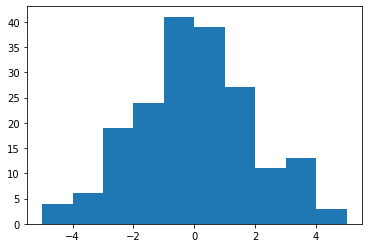

In [11]:
plt.hist(errAvgs / (errStds / np.sqrt(nEstim)), range=(-5,5), bins=10)

In [12]:
print(np.max(errAvgs / (errStds / np.sqrt(nEstim))))
print(np.min(errAvgs / (errStds / np.sqrt(nEstim))))
print(ps[np.argmax(errAvgs / (errStds / np.sqrt(nEstim)))])
print(ps[np.argmin(errAvgs / (errStds / np.sqrt(nEstim)))])

30.762015100200912
-31.92688201756828
0.999
0.001


In [13]:
errAvgs / (errStds / np.sqrt(nEstim))

array([-3.19268820e+01, -8.69990228e-01, -2.17395224e+00, -2.53897618e+00,
       -7.88419139e-01, -4.26055782e+00,  3.37385590e+00,  1.53926661e+00,
       -3.70160668e+00,  4.56522023e-01, -5.74715227e-01,  1.03835039e+00,
       -4.49734636e+00, -1.50753399e+01, -1.94092839e+00,  1.15018635e+00,
        5.85163400e-01, -3.64603625e+00, -2.61612177e+00,  1.14628567e-01,
       -7.34607775e-02, -1.72707285e-02, -1.70976983e-01,  3.00345962e-01,
        2.01082348e+00,  3.06145803e-01, -7.09302750e-04, -2.75835505e+00,
        2.26428992e+00, -4.56996357e+00, -2.52652635e+00,  1.72685542e-01,
       -1.98811241e+00,  1.48677885e+00, -2.31319272e+00,  9.74064425e-01,
       -3.32372978e-01, -3.58148879e+00, -4.17674859e-01,  8.96609300e-01,
        5.70608970e-01, -2.97678000e+00, -6.26130792e-01,  2.61661371e-01,
        4.58572298e-02,  1.47047993e+00, -1.68963341e+00, -1.21213106e+00,
       -4.18159113e-01, -4.89690972e+00,  1.27545631e+01,  3.63950910e+00,
        5.63513653e-01, -

In [18]:
print(ps[np.argsort(np.abs(errAvgs) / errStds)[-10:]])
print((errAvgs / (errStds / np.sqrt(nEstim)))[np.argsort(np.abs(errAvgs) / errStds)[-10:]])

[0.68962 0.34531 0.97405 0.31038 0.7495  0.2505  0.06587 0.93413 0.999
 0.001  ]
[  6.46818199  -7.08763305   7.26760024  -8.20965722 -10.26285455
  12.7545631  -15.07533993  15.08462758  30.7620151  -31.92688202]
